In [1]:
import torch
print(torch.cuda.is_available())		 # 查看GPu设备是否可用
print(torch.cuda.device_count()) 		 # 查看GPu设备数量
print(torch.cuda.get_device_name())   	 # 查看当前GPu设备名称，默认设备id从0开始
print(torch.cuda.current_device())

True
1
Tesla V100S-PCIE-32GB
0


## ETT dataset
* use pre-trained position embedding model by llama, and use the gpt2 in the training process
* the 'test_pred_len' can be 96, 192, 336 etc, which means the trained model can handle prediction tasks of varying lengths.

### test_pred_len = 96

In [8]:

import os
import random
import numpy as np
import torch
from exp.exp_long_term_forecasting import Exp_Long_Term_Forecast
from utils.tools import dotdict
fix_seed = 2021
random.seed(fix_seed)
torch.manual_seed(fix_seed)
np.random.seed(fix_seed)

args = dotdict()
args.root_path = './dataset/ETT-small/'
args.data_path ='ETTh1.csv' 
args.model_id='ETTh1_672_96'
args.model = 'AutoTimes_Gpt2'
args.data = 'ETTh1'
args.features = 'M'
args.seq_len = 672 # length of input（train） series
args.label_len = 576 # length of prefix of decoder（decoder 用的前缀长度）
args.token_len = 96 # 模型每次预测长度（AutoTimes 的预测是 token_len 为窗口的多步滚动预测）
args.test_seq_len = 672
args.test_label_len = 576
args.test_pred_len = 96 # test_pred_len 可能不是 token_len 的整数倍 → 需要多轮推理
args.batch_size = 256
args.learning_rate = 0.002
args.mlp_hidden_layers = 0
args.train_epochs = 10
args.use_amp = True
args.cosine = True
args.tmax = 10
args.mix_embeds = True
args.drop_last = True
args.checkpoints = './checkpoints/'
args.val_set_shuffle = True
args.seasonal_patterns = 'Monthly'
args.dropout = 0.1
args.llm_ckp_dir = './gpt2'
args.mlp_hidden_dim = 256
args.mlp_activation = 'tanh'
args.num_workers = 10
args.patience = 3
args.des = 'test'
args.loss = 'MSE'
args.lradj = 'type1'
args.weight_decay = 0
args.test_dir = './test'
args.test_file_name = 'checkpoint.pth'
args.gpu = 0
args.visualize = True
print('Args in experiment:')
print(args)

Args in experiment:
{'root_path': './dataset/ETT-small/', 'data_path': 'ETTh1.csv', 'model_id': 'ETTh1_672_96', 'model': 'AutoTimes_Gpt2', 'data': 'ETTh1', 'features': 'M', 'seq_len': 672, 'label_len': 576, 'token_len': 96, 'test_seq_len': 672, 'test_label_len': 576, 'test_pred_len': 96, 'batch_size': 256, 'learning_rate': 0.002, 'mlp_hidden_layers': 0, 'train_epochs': 10, 'use_amp': True, 'cosine': True, 'tmax': 10, 'mix_embeds': True, 'drop_last': True, 'checkpoints': './checkpoints/', 'val_set_shuffle': True, 'seasonal_patterns': 'Monthly', 'dropout': 0.1, 'llm_ckp_dir': './gpt2', 'mlp_hidden_dim': 256, 'mlp_activation': 'tanh', 'num_workers': 10, 'patience': 3, 'des': 'test', 'loss': 'MSE', 'lradj': 'type1', 'weight_decay': 0, 'test_dir': './test', 'test_file_name': 'checkpoint.pth', 'gpu': 0, 'visualize': True}


In [9]:

os.environ["CUDA_VISIBLE_DEVICES"] = '0'
exp = Exp_Long_Term_Forecast(args)
# setting record of experiments
setting = '{}_{}_{}_sl{}_ll{}_tl{}_lr{}_bt{}_wd{}_hd{}_hl{}_cos{}_mix{}_{}'.format(
    args.model_id,
    args.model,
    args.data,
    args.seq_len,
    args.label_len,
    args.token_len,
    args.learning_rate,
    args.batch_size,
    args.weight_decay,
    args.mlp_hidden_dim,
    args.mlp_hidden_layers,
    args.cosine,
    args.mix_embeds,
    args.des)
print('>>>>>>>start training : {}>>>>>>>>>>>>>>>>>>>>>>>>>>'.format(setting))
exp.train(setting)
print('>>>>>>>testing : {}<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<'.format(setting))
exp.test(setting)
torch.cuda.empty_cache()

cuda:0
use linear as tokenizer and detokenizer
>>>>>>>start training : ETTh1_672_96_AutoTimes_Gpt2_ETTh1_sl672_ll576_tl96_lr0.002_bt256_wd0_hd256_hl0_cosTrue_mixTrue_test>>>>>>>>>>>>>>>>>>>>>>>>>>
train 55111
val 19495
test 19495
add_scale torch.float32 torch.Size([])
time_embed_proj.weight torch.float32 torch.Size([768, 4096])
time_embed_proj.bias torch.float32 torch.Size([768])
encoder.weight torch.float32 torch.Size([768, 96])
encoder.bias torch.float32 torch.Size([768])
decoder.weight torch.float32 torch.Size([96, 768])
decoder.bias torch.float32 torch.Size([96])
next learning rate is 0.002
	iters: 100, epoch: 1 | loss: 0.5171575
	speed: 0.0716s/iter; left time: 146.9115s
	iters: 200, epoch: 1 | loss: 0.4326257
	speed: 0.0611s/iter; left time: 119.1108s
Epoch: 1 cost time: 14.294549703598022
Epoch: 1, Steps: 215 | Train Loss: 0.7995242 Vali Loss: 0.7462582 Test Loss: 0.4822103
Validation loss decreased (inf --> 0.746258).
lr = 0.0019510568
	iters: 100, epoch: 2 | loss: 0.4111890
	s

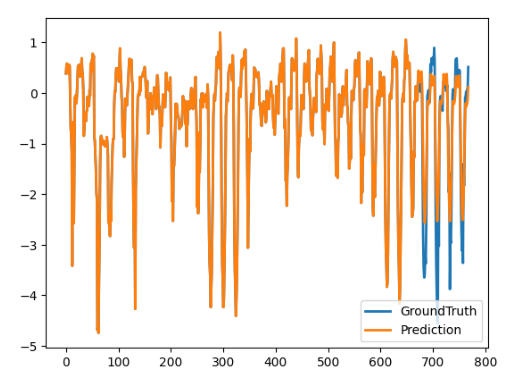

In [14]:
import matplotlib.pyplot as plt
from PIL import Image
%matplotlib inline
img = Image.open('/root/AutoTimes-main/test_results/ETTh1_672_96_AutoTimes_Gpt2_ETTh1_sl672_ll576_tl96_lr0.002_bt256_wd0_hd256_hl0_cosTrue_mixTrue_test/96/0.png')
# plt.get_fignums()
# 使用matplotlib显示图片
plt.imshow(img)
plt.axis('off') 
plt.show()

### test_pred_len = 192

In [15]:
args = dotdict()
args.root_path = './dataset/ETT-small/'
args.data_path ='ETTh1.csv'
args.model_id='ETTh1_672_96'
args.model = 'AutoTimes_Gpt2'
args.data = 'ETTh1'
args.features = 'M'
args.seq_len = 672 # length of input（train） series
args.label_len = 576 # length of prefix of decoder（decoder 用的前缀长度）
args.token_len = 96 # 模型每次预测长度（AutoTimes 的预测是 token_len 为窗口的多步滚动预测）
args.test_seq_len = 672
args.test_label_len = 576
args.test_pred_len = 192 # test_pred_len 可能不是 token_len 的整数倍 → 需要多轮推理
args.batch_size = 256
args.learning_rate = 0.002
args.mlp_hidden_layers = 0
args.train_epochs = 10
args.use_amp = True
args.cosine = True
args.tmax = 10
args.mix_embeds = True
args.drop_last = True
args.checkpoints = './checkpoints/'
args.val_set_shuffle = True
args.seasonal_patterns = 'Monthly'
args.dropout = 0.1
args.llm_ckp_dir = './gpt2'
args.mlp_hidden_dim = 256
args.mlp_activation = 'tanh'
args.num_workers = 10
args.patience = 3
args.des = 'test'
args.loss = 'MSE'
args.lradj = 'type1'
args.weight_decay = 0
args.test_dir = './test'
args.test_file_name = 'checkpoint.pth'
args.gpu = 0
args.visualize = True
print('Args in experiment:')
print(args)

Args in experiment:
{'root_path': './dataset/ETT-small/', 'data_path': 'ETTh1.csv', 'model_id': 'ETTh1_672_96', 'model': 'AutoTimes_Gpt2', 'data': 'ETTh1', 'features': 'M', 'seq_len': 672, 'label_len': 576, 'token_len': 96, 'test_seq_len': 672, 'test_label_len': 576, 'test_pred_len': 192, 'batch_size': 256, 'learning_rate': 0.002, 'mlp_hidden_layers': 0, 'train_epochs': 10, 'use_amp': True, 'cosine': True, 'tmax': 10, 'mix_embeds': True, 'drop_last': True, 'checkpoints': './checkpoints/', 'val_set_shuffle': True, 'seasonal_patterns': 'Monthly', 'dropout': 0.1, 'llm_ckp_dir': './gpt2', 'mlp_hidden_dim': 256, 'mlp_activation': 'tanh', 'num_workers': 10, 'patience': 3, 'des': 'test', 'loss': 'MSE', 'lradj': 'type1', 'weight_decay': 0, 'test_dir': './test', 'test_file_name': 'checkpoint.pth', 'gpu': 0, 'visualize': True}


cuda:0
use linear as tokenizer and detokenizer
>>>>>>>start training : ETTh1_672_96_AutoTimes_Gpt2_ETTh1_sl672_ll576_tl96_lr0.002_bt256_wd0_hd256_hl0_cosTrue_mixTrue_test>>>>>>>>>>>>>>>>>>>>>>>>>>
train 55111
val 19495
test 18823
add_scale torch.float32 torch.Size([])
time_embed_proj.weight torch.float32 torch.Size([768, 4096])
time_embed_proj.bias torch.float32 torch.Size([768])
encoder.weight torch.float32 torch.Size([768, 96])
encoder.bias torch.float32 torch.Size([768])
decoder.weight torch.float32 torch.Size([96, 768])
decoder.bias torch.float32 torch.Size([96])
next learning rate is 0.002
	iters: 100, epoch: 1 | loss: 0.5276202
	speed: 0.0701s/iter; left time: 143.6929s
	iters: 200, epoch: 1 | loss: 0.4426950
	speed: 0.0602s/iter; left time: 117.4917s
Epoch: 1 cost time: 14.097430944442749
Epoch: 1, Steps: 215 | Train Loss: 0.7069335 Vali Loss: 0.7847502 Test Loss: 0.5207188
Validation loss decreased (inf --> 0.784750).
lr = 0.0019510568
	iters: 100, epoch: 2 | loss: 0.3466574
	s

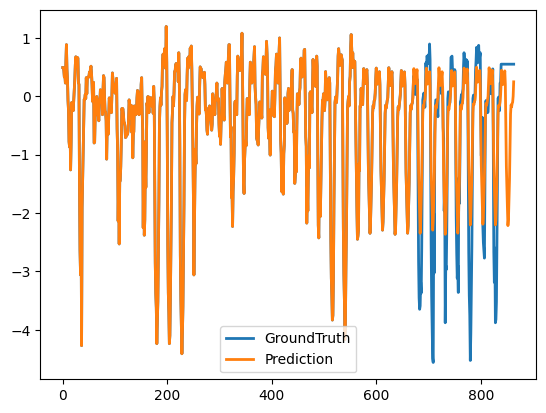

In [16]:

os.environ["CUDA_VISIBLE_DEVICES"] = '0'
exp = Exp_Long_Term_Forecast(args)
# setting record of experiments
setting = '{}_{}_{}_sl{}_ll{}_tl{}_lr{}_bt{}_wd{}_hd{}_hl{}_cos{}_mix{}_{}'.format(
    args.model_id,
    args.model,
    args.data,
    args.seq_len,
    args.label_len,
    args.token_len,
    args.learning_rate,
    args.batch_size,
    args.weight_decay,
    args.mlp_hidden_dim,
    args.mlp_hidden_layers,
    args.cosine,
    args.mix_embeds,
    args.des)
print('>>>>>>>start training : {}>>>>>>>>>>>>>>>>>>>>>>>>>>'.format(setting))
exp.train(setting)
print('>>>>>>>testing : {}<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<'.format(setting))
exp.test(setting)
torch.cuda.empty_cache()

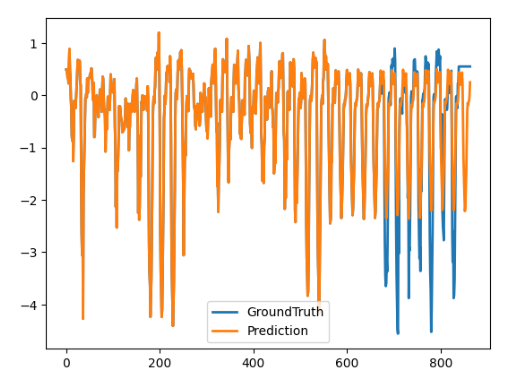

In [17]:
import matplotlib.pyplot as plt
from PIL import Image
%matplotlib inline
img = Image.open('/root/AutoTimes-main/test_results/ETTh1_672_96_AutoTimes_Gpt2_ETTh1_sl672_ll576_tl96_lr0.002_bt256_wd0_hd256_hl0_cosTrue_mixTrue_test/192/0.png')
# plt.get_fignums()
# 使用matplotlib显示图片
plt.imshow(img)
plt.axis('off')
plt.show()

### test_pred_len = 336

In [18]:
args = dotdict()
args.root_path = './dataset/ETT-small/'
args.data_path ='ETTh1.csv'
args.model_id='ETTh1_672_96'
args.model = 'AutoTimes_Gpt2'
args.data = 'ETTh1'
args.features = 'M'
args.seq_len = 672 # length of input（train） series
args.label_len = 576 # length of prefix of decoder（decoder 用的前缀长度）
args.token_len = 96 # 模型每次预测长度（AutoTimes 的预测是 token_len 为窗口的多步滚动预测）
args.test_seq_len = 672
args.test_label_len = 576
args.test_pred_len = 336 # test_pred_len 可能不是 token_len 的整数倍 → 需要多轮推理
args.batch_size = 256
args.learning_rate = 0.002
args.mlp_hidden_layers = 0
args.train_epochs = 10
args.use_amp = True
args.cosine = True
args.tmax = 10
args.mix_embeds = True
args.drop_last = True
args.checkpoints = './checkpoints/'
args.val_set_shuffle = True
args.seasonal_patterns = 'Monthly'
args.dropout = 0.1
args.llm_ckp_dir = './gpt2'
args.mlp_hidden_dim = 256
args.mlp_activation = 'tanh'
args.num_workers = 10
args.patience = 3
args.des = 'test'
args.loss = 'MSE'
args.lradj = 'type1'
args.weight_decay = 0
args.test_dir = './test'
args.test_file_name = 'checkpoint.pth'
args.gpu = 0
args.visualize = True
print('Args in experiment:')
print(args)

Args in experiment:
{'root_path': './dataset/ETT-small/', 'data_path': 'ETTh1.csv', 'model_id': 'ETTh1_672_96', 'model': 'AutoTimes_Gpt2', 'data': 'ETTh1', 'features': 'M', 'seq_len': 672, 'label_len': 576, 'token_len': 96, 'test_seq_len': 672, 'test_label_len': 576, 'test_pred_len': 336, 'batch_size': 256, 'learning_rate': 0.002, 'mlp_hidden_layers': 0, 'train_epochs': 10, 'use_amp': True, 'cosine': True, 'tmax': 10, 'mix_embeds': True, 'drop_last': True, 'checkpoints': './checkpoints/', 'val_set_shuffle': True, 'seasonal_patterns': 'Monthly', 'dropout': 0.1, 'llm_ckp_dir': './gpt2', 'mlp_hidden_dim': 256, 'mlp_activation': 'tanh', 'num_workers': 10, 'patience': 3, 'des': 'test', 'loss': 'MSE', 'lradj': 'type1', 'weight_decay': 0, 'test_dir': './test', 'test_file_name': 'checkpoint.pth', 'gpu': 0, 'visualize': True}


cuda:0
use linear as tokenizer and detokenizer
>>>>>>>start training : ETTh1_672_96_AutoTimes_Gpt2_ETTh1_sl672_ll576_tl96_lr0.002_bt256_wd0_hd256_hl0_cosTrue_mixTrue_test>>>>>>>>>>>>>>>>>>>>>>>>>>
train 55111
val 19495
test 17815
add_scale torch.float32 torch.Size([])
time_embed_proj.weight torch.float32 torch.Size([768, 4096])
time_embed_proj.bias torch.float32 torch.Size([768])
encoder.weight torch.float32 torch.Size([768, 96])
encoder.bias torch.float32 torch.Size([768])
decoder.weight torch.float32 torch.Size([96, 768])
decoder.bias torch.float32 torch.Size([96])
next learning rate is 0.002
	iters: 100, epoch: 1 | loss: 0.4702958
	speed: 0.0705s/iter; left time: 144.6473s
	iters: 200, epoch: 1 | loss: 0.4261464
	speed: 0.0640s/iter; left time: 124.7846s
Epoch: 1 cost time: 14.474131107330322
Epoch: 1, Steps: 215 | Train Loss: 0.8030651 Vali Loss: 0.8388184 Test Loss: 0.5639648
Validation loss decreased (inf --> 0.838818).
lr = 0.0019510568
	iters: 100, epoch: 2 | loss: 0.4175553
	s

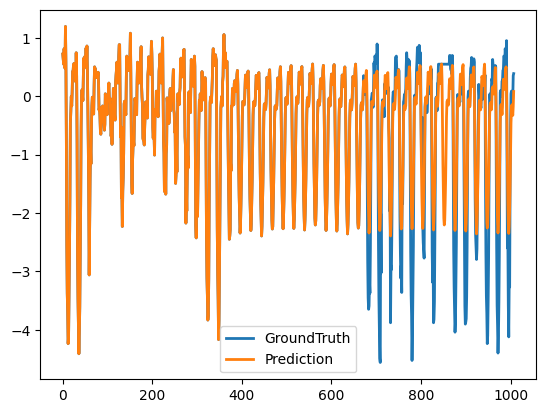

In [20]:

os.environ["CUDA_VISIBLE_DEVICES"] = '0'
exp = Exp_Long_Term_Forecast(args)
# setting record of experiments
setting = '{}_{}_{}_sl{}_ll{}_tl{}_lr{}_bt{}_wd{}_hd{}_hl{}_cos{}_mix{}_{}'.format(
    args.model_id,
    args.model,
    args.data,
    args.seq_len,
    args.label_len,
    args.token_len,
    args.learning_rate,
    args.batch_size,
    args.weight_decay,
    args.mlp_hidden_dim,
    args.mlp_hidden_layers,
    args.cosine,
    args.mix_embeds,
    args.des)
print('>>>>>>>start training : {}>>>>>>>>>>>>>>>>>>>>>>>>>>'.format(setting))
exp.train(setting)
print('>>>>>>>testing : {}<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<'.format(setting))
exp.test(setting)
torch.cuda.empty_cache()

## ELC dataset
* use pre-trained position embedding model by gpt2, and use the gpt2 in the training process

In [7]:
import os
import random
import numpy as np
import torch
from exp.exp_long_term_forecasting import Exp_Long_Term_Forecast
from utils.tools import dotdict
fix_seed = 2021
random.seed(fix_seed)
torch.manual_seed(fix_seed)
np.random.seed(fix_seed)

args = dotdict()
args.root_path = './dataset/electricity/'
args.data_path = 'electricity.csv'
args.model_id = 'electricity_672_96'
args.model = 'AutoTimes_Gpt2'
args.data = 'custom'
args.features = 'M'
args.seq_len = 672  # length of input（train） series
args.label_len = 576  # length of prefix of decoder（decoder 用的前缀长度）
args.token_len = 96  # 模型每次预测长度（AutoTimes 的预测是 token_len 为窗口的多步滚动预测）
args.test_seq_len = 672
args.test_label_len = 576
args.test_pred_len = 96  # test_pred_len 可能不是 token_len 的整数倍 → 需要多轮推理
args.batch_size = 1024
args.learning_rate = 0.002
args.mlp_hidden_layers = 0
args.train_epochs = 10
args.use_amp = True
args.cosine = True
args.tmax = 10
args.mix_embeds = True
args.drop_last = True
args.checkpoints = './checkpoints/'
args.val_set_shuffle = True
args.seasonal_patterns = 'Monthly'
args.dropout = 0.1
args.llm_ckp_dir = './gpt2'
args.mlp_hidden_dim = 512
args.mlp_activation = 'tanh'
args.num_workers = 10
args.patience = 3
args.des = 'test'
args.loss = 'MSE'
args.lradj = 'type1'
args.weight_decay = 0
args.test_dir = './test'
args.test_file_name = 'checkpoint.pth'
args.gpu = 0
args.visualize = True
print('Args in experiment:')
print(args)

Args in experiment:
{'root_path': './dataset/electricity/', 'data_path': 'electricity.csv', 'model_id': 'electricity_672_96', 'model': 'AutoTimes_Gpt2', 'data': 'custom', 'features': 'M', 'seq_len': 672, 'label_len': 576, 'token_len': 96, 'test_seq_len': 672, 'test_label_len': 576, 'test_pred_len': 96, 'batch_size': 1024, 'learning_rate': 0.002, 'mlp_hidden_layers': 0, 'train_epochs': 10, 'use_amp': True, 'cosine': True, 'tmax': 10, 'mix_embeds': True, 'drop_last': True, 'checkpoints': './checkpoints/', 'val_set_shuffle': True, 'seasonal_patterns': 'Monthly', 'dropout': 0.1, 'llm_ckp_dir': './gpt2', 'mlp_hidden_dim': 512, 'mlp_activation': 'tanh', 'num_workers': 10, 'patience': 3, 'des': 'test', 'loss': 'MSE', 'lradj': 'type1', 'weight_decay': 0, 'test_dir': './test', 'test_file_name': 'checkpoint.pth', 'gpu': 0, 'visualize': True}


cuda:0
use linear as tokenizer and detokenizer
this is the new file
>>>>>>>start training : electricity_672_96_AutoTimes_Gpt2_custom_sl672_ll576_tl96_lr0.002_bt1024_wd0_hd512_hl0_cosTrue_mixTrue_test>>>>>>>>>>>>>>>>>>>>>>>>>>
train 1112586
val 164031
test 357594
add_scale torch.float32 torch.Size([])
encoder.weight torch.float32 torch.Size([768, 96])
encoder.bias torch.float32 torch.Size([768])
decoder.weight torch.float32 torch.Size([96, 768])
decoder.bias torch.float32 torch.Size([96])
next learning rate is 0.002
	iters: 100, epoch: 1 | loss: 0.3871123
	speed: 0.1514s/iter; left time: 1629.4729s
	iters: 200, epoch: 1 | loss: 0.3157082
	speed: 0.1435s/iter; left time: 1529.4786s
	iters: 300, epoch: 1 | loss: 0.2999072
	speed: 0.1441s/iter; left time: 1522.3240s
	iters: 400, epoch: 1 | loss: 0.2786839
	speed: 0.1442s/iter; left time: 1508.6180s
	iters: 500, epoch: 1 | loss: 0.2733339
	speed: 0.1449s/iter; left time: 1501.4952s
	iters: 600, epoch: 1 | loss: 0.2695524
	speed: 0.1442s/ite

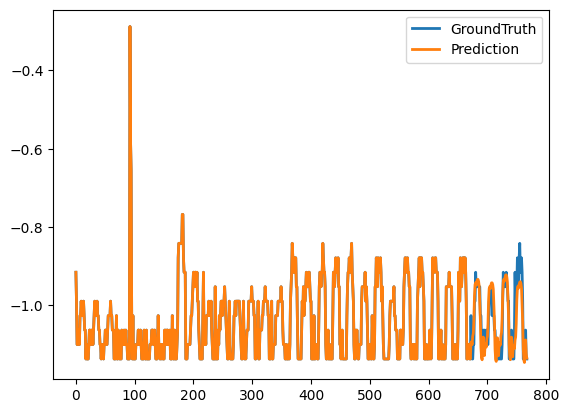

In [8]:

os.environ["CUDA_VISIBLE_DEVICES"] = '0'
exp = Exp_Long_Term_Forecast(args)
# setting record of experiments
setting = '{}_{}_{}_sl{}_ll{}_tl{}_lr{}_bt{}_wd{}_hd{}_hl{}_cos{}_mix{}_{}'.format(
    args.model_id,
    args.model,
    args.data,
    args.seq_len,
    args.label_len,
    args.token_len,
    args.learning_rate,
    args.batch_size,
    args.weight_decay,
    args.mlp_hidden_dim,
    args.mlp_hidden_layers,
    args.cosine,
    args.mix_embeds,
    args.des)
print('>>>>>>>start training : {}>>>>>>>>>>>>>>>>>>>>>>>>>>'.format(setting))
exp.train(setting)
print('>>>>>>>testing : {}<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<'.format(setting))
exp.test(setting)
torch.cuda.empty_cache()

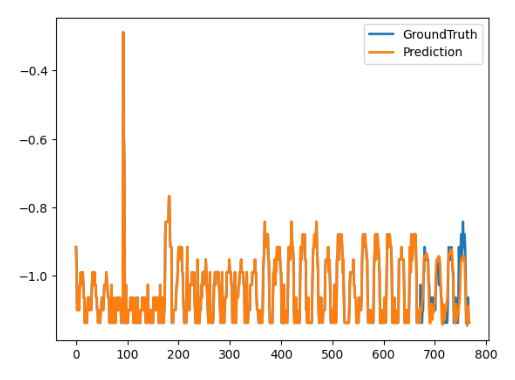

In [9]:
import matplotlib.pyplot as plt
from PIL import Image
%matplotlib inline
img = Image.open('/root/AutoTimes-main/test_results/electricity_672_96_AutoTimes_Gpt2_custom_sl672_ll576_tl96_lr0.002_bt1024_wd0_hd512_hl0_cosTrue_mixTrue_test/96/0.png')
# plt.get_fignums()
# 使用matplotlib显示图片
plt.imshow(img)
plt.axis('off')
plt.show()

## Traffic dataset
* use pre-trained position embedding model by gpt2, and use the gpt2 in the training process

In [4]:
import os
import random
import numpy as np
import torch
from exp.exp_long_term_forecasting import Exp_Long_Term_Forecast
from utils.tools import dotdict
fix_seed = 2021
random.seed(fix_seed)
torch.manual_seed(fix_seed)
np.random.seed(fix_seed)

args = dotdict()
args.root_path = './dataset/traffic/'
args.data_path = 'traffic.csv'
args.model_id = 'traffic_672_96'
args.model = 'AutoTimes_Gpt2'
args.data = 'custom'
args.features = 'M'
args.seq_len = 672  # length of input（train） series
args.label_len = 576  # length of prefix of decoder（decoder 用的前缀长度）
args.token_len = 96  # 模型每次预测长度（AutoTimes 的预测是 token_len 为窗口的多步滚动预测）
args.test_seq_len = 672
args.test_label_len = 576
args.test_pred_len = 96  # test_pred_len 可能不是 token_len 的整数倍 → 需要多轮推理
args.batch_size = 256
args.learning_rate = 0.0002
args.mlp_hidden_layers = 0
args.train_epochs = 10
args.use_amp = True
args.cosine = True
args.tmax = 10
args.mix_embeds = True
args.drop_last = True
args.checkpoints = './checkpoints/'
args.val_set_shuffle = True
args.seasonal_patterns = 'Monthly'
args.dropout = 0.1
args.llm_ckp_dir = './gpt2'
args.mlp_hidden_dim = 512
args.mlp_activation = 'tanh'
args.num_workers = 10
args.patience = 3
args.des = 'test'
args.loss = 'MSE'
args.lradj = 'type1'
args.weight_decay = 0
args.test_dir = './test'
args.test_file_name = 'checkpoint.pth'
args.gpu = 0
args.visualize = True
print('Args in experiment:')
print(args)

Args in experiment:
{'root_path': './dataset/traffic/', 'data_path': 'traffic.csv', 'model_id': 'traffic_672_96', 'model': 'AutoTimes_Gpt2', 'data': 'custom', 'features': 'M', 'seq_len': 672, 'label_len': 576, 'token_len': 96, 'test_seq_len': 672, 'test_label_len': 576, 'test_pred_len': 96, 'batch_size': 256, 'learning_rate': 0.0002, 'mlp_hidden_layers': 0, 'train_epochs': 10, 'use_amp': True, 'cosine': True, 'tmax': 10, 'mix_embeds': True, 'drop_last': True, 'checkpoints': './checkpoints/', 'val_set_shuffle': True, 'seasonal_patterns': 'Monthly', 'dropout': 0.1, 'llm_ckp_dir': './gpt2', 'mlp_hidden_dim': 512, 'mlp_activation': 'tanh', 'num_workers': 10, 'patience': 3, 'des': 'test', 'loss': 'MSE', 'lradj': 'type1', 'weight_decay': 0, 'test_dir': './test', 'test_file_name': 'checkpoint.pth', 'gpu': 0, 'visualize': True}


cuda:0
use linear as tokenizer and detokenizer
this is the new file
>>>>>>>start training : traffic_672_96_AutoTimes_Gpt2_custom_sl672_ll576_tl96_lr0.0002_bt256_wd0_hd512_hl0_cosTrue_mixTrue_test>>>>>>>>>>>>>>>>>>>>>>>>>>
train 1066294
val 166366
test 411174
add_scale torch.float32 torch.Size([])
encoder.weight torch.float32 torch.Size([768, 96])
encoder.bias torch.float32 torch.Size([768])
decoder.weight torch.float32 torch.Size([96, 768])
decoder.bias torch.float32 torch.Size([96])
next learning rate is 0.0002
	iters: 100, epoch: 1 | loss: 1.6909564
	speed: 0.0585s/iter; left time: 2429.7953s
	iters: 200, epoch: 1 | loss: 1.0808966
	speed: 0.0507s/iter; left time: 2100.4422s
	iters: 300, epoch: 1 | loss: 0.8562047
	speed: 0.0502s/iter; left time: 2075.0773s
	iters: 400, epoch: 1 | loss: 0.7689958
	speed: 0.0535s/iter; left time: 2208.2453s
	iters: 500, epoch: 1 | loss: 0.7215561
	speed: 0.0509s/iter; left time: 2094.4178s
	iters: 600, epoch: 1 | loss: 0.6756082
	speed: 0.0504s/iter; 

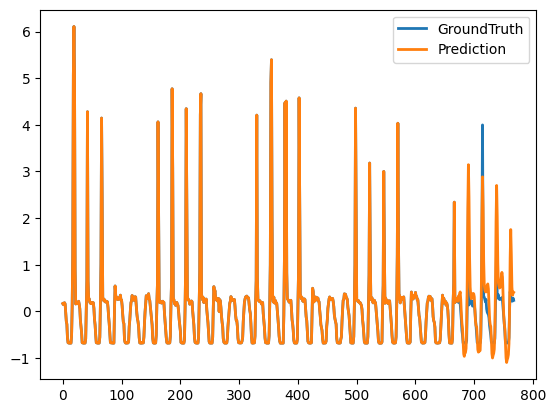

In [5]:

os.environ["CUDA_VISIBLE_DEVICES"] = '0'
exp = Exp_Long_Term_Forecast(args)
# setting record of experiments
setting = '{}_{}_{}_sl{}_ll{}_tl{}_lr{}_bt{}_wd{}_hd{}_hl{}_cos{}_mix{}_{}'.format(
    args.model_id,
    args.model,
    args.data,
    args.seq_len,
    args.label_len,
    args.token_len,
    args.learning_rate,
    args.batch_size,
    args.weight_decay,
    args.mlp_hidden_dim,
    args.mlp_hidden_layers,
    args.cosine,
    args.mix_embeds,
    args.des)
print('>>>>>>>start training : {}>>>>>>>>>>>>>>>>>>>>>>>>>>'.format(setting))
exp.train(setting)
print('>>>>>>>testing : {}<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<'.format(setting))
exp.test(setting)
torch.cuda.empty_cache()

## Weather dataset
*use pre-trained position embedding model by gpt2, and use the gpt2 in the training process

In [1]:
import os
import random
import numpy as np
import torch
from exp.exp_long_term_forecasting import Exp_Long_Term_Forecast
from utils.tools import dotdict
fix_seed = 2021
random.seed(fix_seed)
torch.manual_seed(fix_seed)
np.random.seed(fix_seed)

args = dotdict()
args.root_path = './dataset/weather/'
args.data_path = 'weather.csv'
args.model_id = 'weather_672_96'
args.model = 'AutoTimes_Gpt2'
args.data = 'custom'
args.features = 'M'
args.seq_len = 672  # length of input（train） series
args.label_len = 576  # length of prefix of decoder（decoder 用的前缀长度）
args.token_len = 96  # 模型每次预测长度（AutoTimes 的预测是 token_len 为窗口的多步滚动预测）
args.test_seq_len = 672
args.test_label_len = 576
args.test_pred_len = 96  # test_pred_len 可能不是 token_len 的整数倍 → 需要多轮推理
args.batch_size = 1024
args.learning_rate = 0.0005
args.mlp_hidden_layers = 0
args.train_epochs = 10
args.use_amp = True
args.cosine = True
args.tmax = 10
args.mix_embeds = True
args.drop_last = True
args.checkpoints = './checkpoints/'
args.val_set_shuffle = True
args.seasonal_patterns = 'Monthly'
args.dropout = 0.1
args.llm_ckp_dir = './gpt2'
args.mlp_hidden_dim = 512
args.mlp_activation = 'tanh'
args.num_workers = 10
args.patience = 3
args.des = 'test'
args.loss = 'MSE'
args.lradj = 'type1'
args.weight_decay = 0
args.test_dir = './test'
args.test_file_name = 'checkpoint.pth'
args.gpu = 0
args.visualize = True
print('Args in experiment:')
print(args)

Args in experiment:
{'root_path': './dataset/weather/', 'data_path': 'weather.csv', 'model_id': 'weather_672_96', 'model': 'AutoTimes_Gpt2', 'data': 'custom', 'features': 'M', 'seq_len': 672, 'label_len': 576, 'token_len': 96, 'test_seq_len': 672, 'test_label_len': 576, 'test_pred_len': 96, 'batch_size': 1024, 'learning_rate': 0.0005, 'mlp_hidden_layers': 0, 'train_epochs': 10, 'use_amp': True, 'cosine': True, 'tmax': 10, 'mix_embeds': True, 'drop_last': True, 'checkpoints': './checkpoints/', 'val_set_shuffle': True, 'seasonal_patterns': 'Monthly', 'dropout': 0.1, 'llm_ckp_dir': './gpt2', 'mlp_hidden_dim': 512, 'mlp_activation': 'tanh', 'num_workers': 10, 'patience': 3, 'des': 'test', 'loss': 'MSE', 'lradj': 'type1', 'weight_decay': 0, 'test_dir': './test', 'test_file_name': 'checkpoint.pth', 'gpu': 0, 'visualize': True}


In [2]:
os.environ["CUDA_VISIBLE_DEVICES"] = '0'
exp = Exp_Long_Term_Forecast(args)
# setting record of experiments
setting = '{}_{}_{}_sl{}_ll{}_tl{}_lr{}_bt{}_wd{}_hd{}_hl{}_cos{}_mix{}_{}'.format(
    args.model_id,
    args.model,
    args.data,
    args.seq_len,
    args.label_len,
    args.token_len,
    args.learning_rate,
    args.batch_size,
    args.weight_decay,
    args.mlp_hidden_dim,
    args.mlp_hidden_layers,
    args.cosine,
    args.mix_embeds,
    args.des)
print('>>>>>>>start training : {}>>>>>>>>>>>>>>>>>>>>>>>>>>'.format(setting))
exp.train(setting)
print('>>>>>>>testing : {}<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<'.format(setting))
exp.test(setting)
torch.cuda.empty_cache()

cuda:0
use linear as tokenizer and detokenizer
this is the new file
>>>>>>>start training : weather_672_96_AutoTimes_Gpt2_custom_sl672_ll576_tl96_lr0.0005_bt1024_wd0_hd512_hl0_cosTrue_mixTrue_test>>>>>>>>>>>>>>>>>>>>>>>>>>
train 758520
val 108675
test 219324
add_scale torch.float32 torch.Size([])
encoder.weight torch.float32 torch.Size([768, 96])
encoder.bias torch.float32 torch.Size([768])
decoder.weight torch.float32 torch.Size([96, 768])
decoder.bias torch.float32 torch.Size([96])
next learning rate is 0.0005
	iters: 100, epoch: 1 | loss: 0.7306385
	speed: 0.1558s/iter; left time: 1137.5296s
	iters: 200, epoch: 1 | loss: 0.6623017
	speed: 0.1472s/iter; left time: 1059.9137s
	iters: 300, epoch: 1 | loss: 0.4374106
	speed: 0.1476s/iter; left time: 1047.7744s
	iters: 400, epoch: 1 | loss: 0.4700496
	speed: 0.1465s/iter; left time: 1025.6103s
	iters: 500, epoch: 1 | loss: 0.4016574
	speed: 0.1478s/iter; left time: 1020.0408s
	iters: 600, epoch: 1 | loss: 0.3983580
	speed: 0.1479s/iter; 

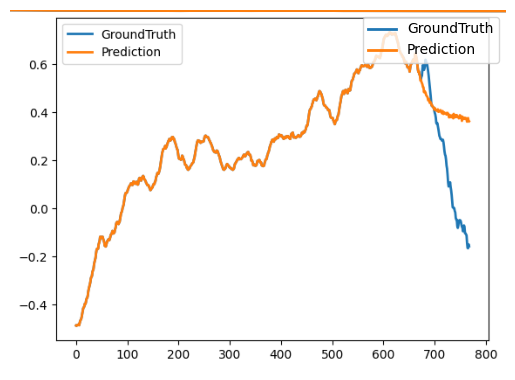

In [3]:
import matplotlib.pyplot as plt
from PIL import Image
%matplotlib inline
img = Image.open('/root/AutoTimes-main/test_results/weather_672_96_AutoTimes_Gpt2_custom_sl672_ll576_tl96_lr0.0005_bt1024_wd0_hd512_hl0_cosTrue_mixTrue_test/96/0.png')
# plt.get_fignums()
# 使用matplotlib显示图片
plt.imshow(img)
plt.axis('off')
plt.show()